In [ ]:
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
zip_path = "/content/drive/MyDrive/GTSRBDataset/dataset.zip"
extract_path = '/content/GTSRB'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt#for visualization
import cv2#computer vision for image processing
from sklearn.metrics import accuracy_score
import tensorflow as tf
from PIL import Image#Python Imaging Library
import os
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical#for classifying images into categories using vectors
from keras.models import Sequential,load_model#sequential - to create a linear stack of layers with a tensor
from keras.layers import Input,Conv2D, MaxPooling2D, Dense, Flatten, Dropout
#Conv2D- creates 2d convolutional models,MaxPooling2D-reduces spatial dimensions, Dense - usedin final layer of classififcation,it is a full neural network
#Flatten- coverts input to1d,Dropout- prevent overfitting

In [ ]:
#This creates an empty list to store all traffic sign images.
data = []
labels = []
classes  = 43
cur_path = os.getcwd()
cur_path                #current location to access the dataset

'/content'

In [ ]:
import os
import cv2
import numpy as np

data = []
labels = []
classes = 43

# CORRECT PATH AFTER EXTRACTION
base_path = "/content/GTSRB"

for i in range(classes):

    path = os.path.join(base_path, 'train', str(i))  #Creates path to current class folder.

    images = os.listdir(path)

    for a in images:

        try:
            img_path = os.path.join(path, a)
            img = cv2.imread(img_path)

            img = cv2.resize(img, (30, 30))

            data.append(img)

            labels.append(i)

        except Exception as e:
            print("Error loading image:", a)
            print(e)

data = np.array(data)
labels = np.array(labels)

print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)

Data Shape: (39209, 30, 30, 3)
Labels Shape: (39209,)


In [ ]:
data
labels

array([ 0,  0,  0, ..., 42, 42, 42])

In [ ]:
#saving for future use
os.makedirs('training', exist_ok=True)# this prevent the folder is already exist
np.save('./training/data',data)
np.save('./training/target',labels)

In [ ]:
data = np.load('./training/data.npy')
data

array([[[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],

        ...,

        [[237, 255, 255],
         [243, 255, 255],
         [250, 255, 255],
         ...,
         [210, 242, 249],
         [100, 141, 166],
         [ 82, 106, 109]],

        [[240, 255, 255],
         [245, 255, 255],
         [251, 255, 255],
         ...,
         [203, 253, 255],
         [ 60,  89, 133],
         [ 42,  51,  58]],

        [[239, 255, 255],
         [246, 255, 255],
         [245, 255, 255],
         ...,
         [213, 254, 255],
        

In [ ]:
labels = np.load('./training/target.npy')
labels

array([ 0,  0,  0, ..., 42, 42, 42])

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(data,labels,test_size= 0.2,random_state = 0)

In [ ]:
X_train,X_test,y_train,y_test

(array([[[[ 48,  54,  56],
          [ 49,  56,  57],
          [ 49,  56,  57],
          ...,
          [ 57,  64,  74],
          [ 57,  65,  73],
          [ 55,  64,  72]],
 
         [[ 45,  51,  52],
          [ 48,  55,  58],
          [ 48,  55,  57],
          ...,
          [ 55,  63,  67],
          [ 56,  64,  70],
          [ 52,  60,  68]],
 
         [[ 44,  53,  55],
          [ 48,  57,  59],
          [ 47,  54,  55],
          ...,
          [ 53,  60,  67],
          [ 54,  61,  68],
          [ 52,  57,  63]],
 
         ...,
 
         [[ 40,  42,  44],
          [ 41,  44,  48],
          [ 41,  44,  48],
          ...,
          [ 50,  48,  49],
          [ 45,  48,  49],
          [ 45,  48,  50]],
 
         [[ 42,  44,  45],
          [ 42,  43,  46],
          [ 42,  42,  46],
          ...,
          [ 48,  48,  51],
          [ 44,  47,  48],
          [ 44,  48,  48]],
 
         [[ 45,  47,  54],
          [ 45,  47,  45],
          [ 41,  39,  39],
   

In [ ]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(31367, 30, 30, 3) (7842, 30, 30, 3) (31367,) (7842,)


In [ ]:
#to_categorical converts data into onehot Encoder format
y_train = to_categorical(y_train,43)
y_test = to_categorical(y_test,43)
y_train,y_test

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]))

In [ ]:
#Building the model
model = Sequential()
#Rectified Linear Unit (ReLU) f(x)=max(0,x)

# Input Layer
model.add(Input(shape=X_train.shape[1:]))        #image dimensions for CNN

# First Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu')) #extracts basic image features

# Second Convolutional Layer
model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu'))

# Max Pooling Layer
model.add(MaxPooling2D(pool_size=(2, 2)))     #Reduce image size.

# Dropout Layer
model.add(Dropout(rate=0.25))          #randomly disabling neurons.
# Third Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu'))

# Fourth Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu'))  #captures more complex image structures.

# Max Pooling Layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# Dropout Layer
model.add(Dropout(rate=0.25))

# Flatten Layer
model.add(Flatten()) #converts multidimensional data into a single vector

# Fully Connected Layer
model.add(Dense(256, activation='relu'))

# Dropout Layer
model.add(Dropout(rate=0.5))
# Output Layer
model.add(Dense(43, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 64)       │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,483 (818.29 KB)

 Trainable params: 209,483 (818.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss = 'categorical_crossentropy',optimizer = 'adam',metrics = ['accuracy'])
#Adam (Adaptive Moment Estimation)

In [ ]:
# Building the model (re-added for robustness against kernel state issues)
model = Sequential()
model.add(Input(shape=X_train.shape[1:]))
model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu'))
model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(43, activation='softmax'))

# Compile the model (re-added for robustness against kernel state issues)
model.compile(loss = 'categorical_crossentropy',optimizer = 'adam',metrics = ['accuracy'])

epochs = 20
history = model.fit(X_train,y_train,batch_size =32,epochs = epochs,validation_data= (X_test,y_test))

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.4286 - loss: 2.0812 - val_accuracy: 0.8273 - val_loss: 0.6185
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7870 - loss: 0.7468 - val_accuracy: 0.9455 - val_loss: 0.2255
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8720 - loss: 0.4755 - val_accuracy: 0.9711 - val_loss: 0.1296
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9043 - loss: 0.3734 - val_accuracy: 0.9751 - val_loss: 0.1130
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9181 - loss: 0.3234 - val_accuracy: 0.9784 - val_loss: 0.0824
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9289 - loss: 0.2870 - val_accuracy: 0.9865 - val_loss: 0.0602
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9356 - loss: 0.2746 - val_accuracy: 0.9760 - val_loss: 0.0982
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9309 - loss: 0.3028 - val_accuracy: 

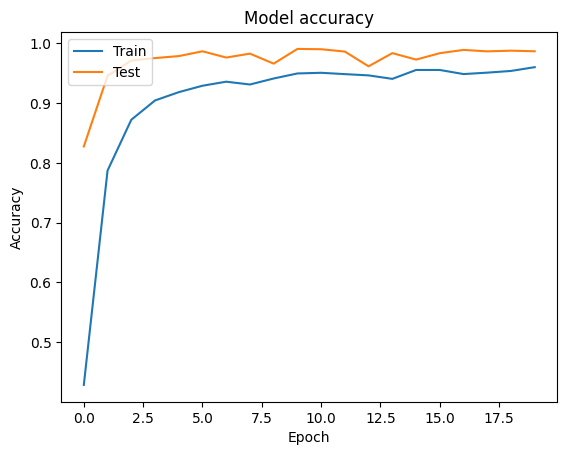

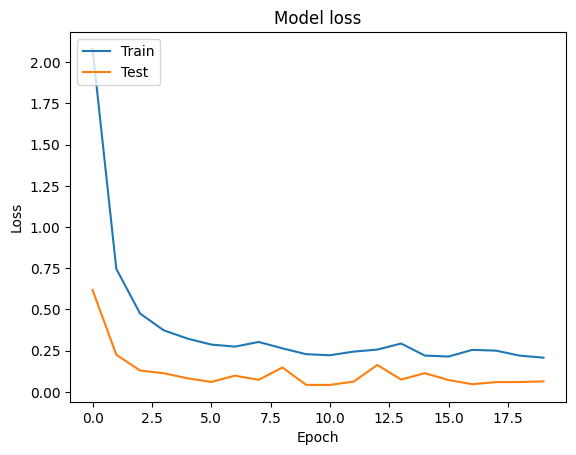

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
import os

def testing(testcsv):
    y_test = pd.read_csv(testcsv)
    label = y_test["ClassId"].values
    imgs = y_test["Path"].values
    data = []

    # Determine the base directory for images from the testcsv path
    base_image_dir = os.path.dirname(testcsv)

    for img_relative_path in imgs:
        # Construct the full image path
        full_image_path = os.path.join(base_image_dir, img_relative_path)
        image = Image.open(full_image_path)
        image = image.resize((30,30))
        data.append(np.array(image))
    X_test = np.array(data)
    return X_test,label

In [ ]:
X_test,label = testing('/content/GTSRB/Test.csv')

In [ ]:
X_test,label

(array([[[[116, 140, 175],
          [116, 138, 171],
          [119, 138, 173],
          ...,
          [102, 119, 150],
          [101, 122, 149],
          [ 93, 112, 139]],
 
         [[116, 142, 177],
          [116, 141, 175],
          [117, 141, 174],
          ...,
          [120, 143, 178],
          [122, 144, 176],
          [122, 142, 174]],
 
         [[118, 142, 174],
          [116, 141, 175],
          [114, 140, 172],
          ...,
          [121, 144, 181],
          [122, 144, 180],
          [119, 142, 178]],
 
         ...,
 
         [[117, 137, 168],
          [115, 135, 165],
          [116, 135, 164],
          ...,
          [116, 138, 170],
          [116, 136, 168],
          [118, 139, 171]],
 
         [[116, 136, 166],
          [115, 134, 167],
          [115, 133, 165],
          ...,
          [114, 135, 168],
          [116, 136, 166],
          [115, 139, 167]],
 
         [[112, 135, 166],
          [111, 134, 165],
          [119, 135, 166],
   

In [ ]:
# Get the predicted probabilities for each class
y_pred_prob = model.predict(X_test)

# For multi-class classification, get the class with the highest probability
y_pred = np.argmax(y_pred_prob, axis=1)

# Display the predicted classes
print(y_pred)

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[16  1 38 ...  5  7 10]


In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(label,y_pred))

0.8016627078384798


Accuracy: 0.8016627078384798

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        60
           1       0.93      0.96      0.94       720
           2       0.98      0.95      0.97       750
           3       0.72      0.95      0.82       450
           4       0.95      0.96      0.95       660
           5       0.78      0.91      0.84       630
           6       0.86      0.85      0.86       150
           7       0.98      0.89      0.93       450
           8       0.88      0.90      0.89       450
           9       0.95      0.93      0.94       480
          10       0.96      0.90      0.93       660
          11       0.87      0.90      0.89       420
          12       0.58      0.42      0.49       690
          13       0.96      0.99      0.98       720
          14       0.74      0.70      0.72       270
          15       0.54      0.62      0.58       210
          16       0.98      

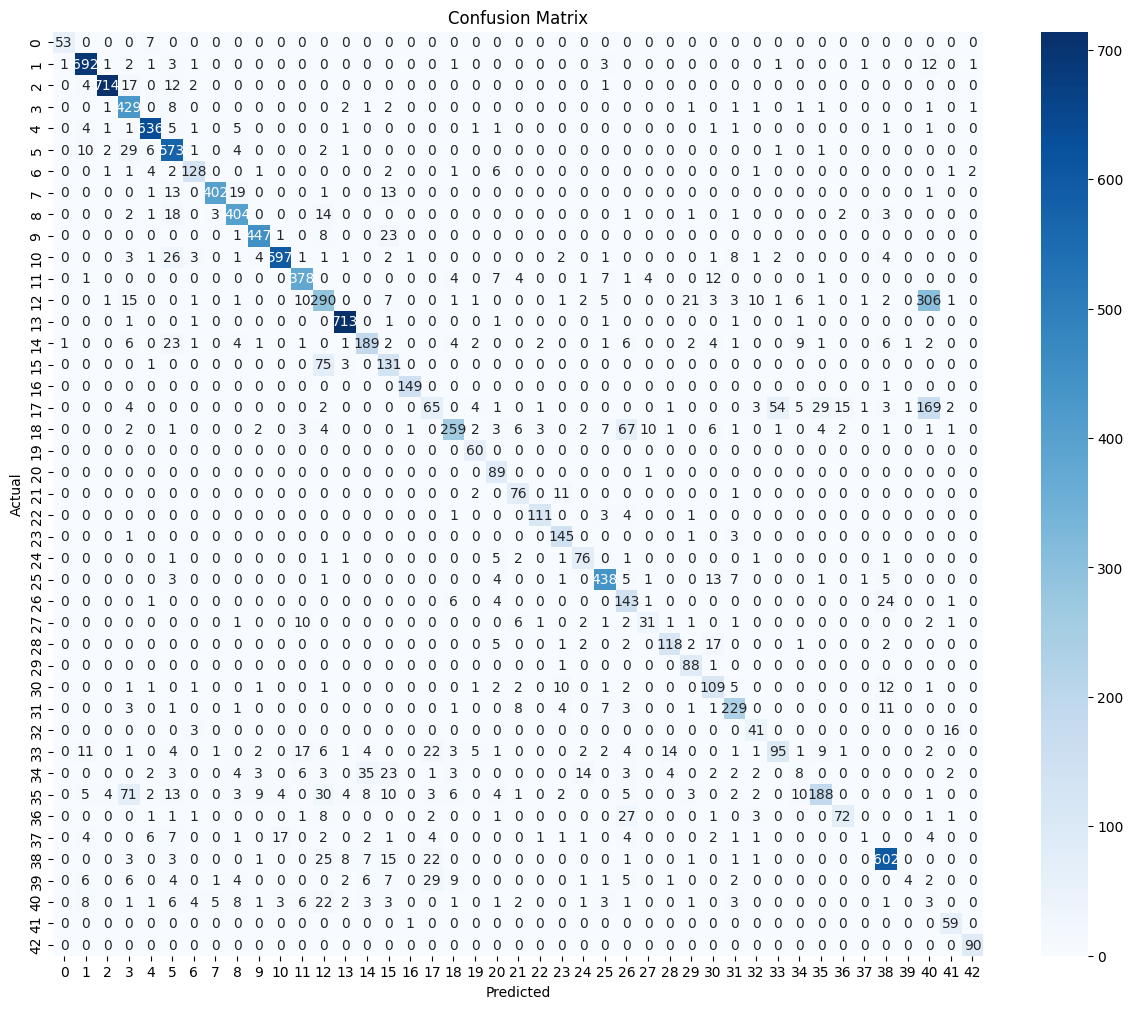

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image

def testing(testcsv):
    y_test = pd.read_csv(testcsv)
    label = y_test["ClassId"].values
    imgs = y_test["Path"].values
    data = []

    # Determine the base directory for images from the testcsv path
    base_image_dir = os.path.dirname(testcsv)

    for img_relative_path in imgs:
        # Construct the full image path
        full_image_path = os.path.join(base_image_dir, img_relative_path)
        image = Image.open(full_image_path)
        image = image.resize((30,30))
        data.append(np.array(image))
    X_test = np.array(data)
    return X_test,label

X_test, label = testing('/content/GTSRB/Test.csv')

# Basic accuracy
acc = accuracy_score(label, y_pred)
print("Accuracy:", acc)

# Classification report (precision, recall, f1-score)
print("\nClassification Report")
print(classification_report(label, y_pred))

# Confusion matrix
cm = confusion_matrix(label, y_pred)

plt.figure(figsize=(15,12))
sns.heatmap(cm, annot=True,fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()